# CO543: Image Processing - Lab 04
## E_21_245_Lab_04

## Segmentation & Image Restoration


#### Import Required Libraries first

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy import ndimage
import os

### Load and Display the Image

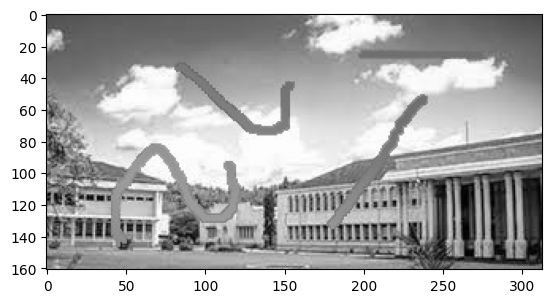

In [3]:
img_path = "Efac.jpg"
gray= cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

# display the original image
plt.imshow(gray,cmap='gray')

### Task 1 — Threshold for Foreground/Background Separation

In [8]:
# Global Thresholding
ret, gloabal_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(gray, 255, 1,
                                        1, 11, 2)

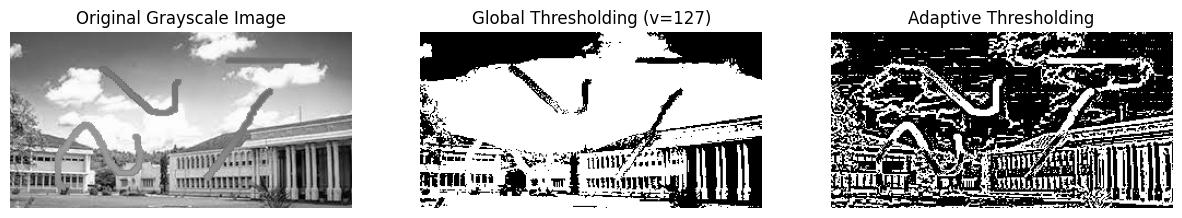

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title('Original Grayscale Image')
plt.imshow(gray,cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Global Thresholding (v=127)')
plt.imshow(gloabal_thresh,cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Adaptive Thresholding')
plt.imshow(adaptive_thresh,cmap='gray')
plt.axis('off')

plt.show()

##### 1. Observation & Description :- 
In the Global Thresholding result, many details are lost. The sky became completely white, and the scribbles are mixed with the dark building parts. But, Adaptive Thresholding gives a better result. We can clearly see the outline of scribbles, the clouds, and the building windows. It is good because it adjusts to the changes in local lighting.

##### 2. Discussion:- 
Global thresholding fails here because the light is not the same everywhere in the outdoor photo (uneven lighting). The sky is very bright, but the building is dark. One single threshold value cannot work for both places. Adaptive thresholding fixes this problem. It calculates a threshold for small small neighborhoods. So, it can find the scribbles and edges correctly, even if the area is in shadow or sunlight.

##### More to Think:-

Question: Is segmentation purely by intensity reliable outdoors? 

Answer: No, it is not reliable. Outside, the light is always changing because of clouds and sun. This creates hard shadows. Shadows change the intensity value of the objects. As we see in the Global Thresholding image, simple intensity segmentation makes mistakes. It thinks shadows are objects or it mixes the object with the background.

### Task 2 — K-Means Pixel Clustering

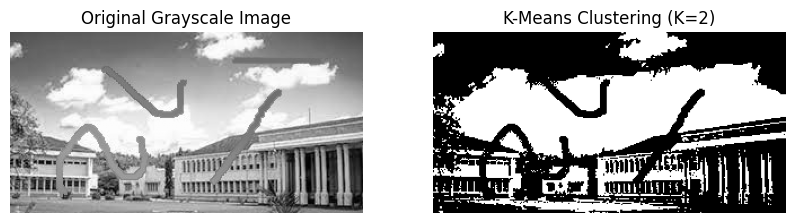

In [13]:
Z = gray.reshape(-1,1)
z = np.float32(Z)

# Define Creteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

# Apply K-Means
K=2
ret,label,center = cv2.kmeans(z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)

# Convert back to unit8 and shape to original image size
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((gray.shape))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Grayscale Image')
plt.imshow(gray,cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('K-Means Clustering (K=2)')
plt.imshow(res2,cmap='gray')
plt.axis('off')
plt.show()

####  Observation & Description:-
 In the K-Means result, the image is split into just black and white. The grey scribbles became black. But, the dark trees on the left and the shadows on the building also became black. The bright sky and the white walls became white. The scribbles are separated from the sky, but they are mixed up with the trees.

#### Discussion :-
 K-Means groups pixels only by their brightness values. It put the scribbles and the trees in the same "black" group because they both have low intensity numbers. The algorithm does not have "semantic understanding," which means it does not know that a tree is an object and a scribble is damage. It just sees that both are dark, so it puts them in the same cluster.

#### More to Think:-
 Question:- When can two different objects fall into one cluster?
  
  Answer:- Two different objects go into one cluster if they have the same color or brightness. For example, in this image, the trees and the scribbles are different things, but K-Means put them together because they are both dark. If we have a red ball and a red apple, K-Means will also put them in the same group because the color is the same.

### Task 3 — Edge Map for Structure Protection

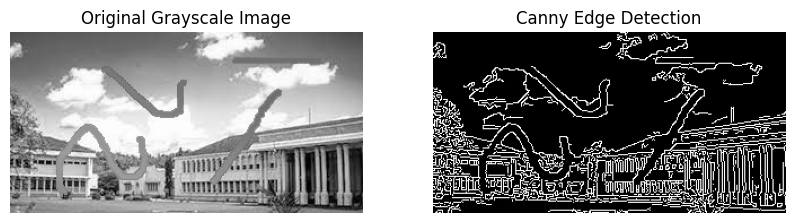

In [14]:
edges = cv2.Canny(gray, 80, 160)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Grayscale Image')
plt.imshow(gray,cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Canny Edge Detection')
plt.imshow(edges,cmap='gray')
plt.axis('off')
plt.show()


#### Observation & Description:-
 I used the Canny edge detector with thresholds 80 and 160. The result is a black image with thin white lines. I can see the straight lines of the building columns and the roof. I can also clearly see the edges of the big grey scribbles in the sky. The edges of the clouds are there too, but they are broken and not continuous.

#### Discussion:-
 The Canny detector finds the edges where the color changes fast. In this image, the true scene structure is the building. These edges are straight, sharp, and geometric. The scribble strokes are the wavy, curved lines that go over the sky and the building. The edge map shows both types of edges. It helps us see where the scribbles are blocking the real object, but it does not remove them.

#### More to Think
 Question:- Do scribbles always have different edge patterns than architecture? 
 Answer:- Usually yes, but not always. Architecture (buildings) usually has straight lines and sharp corners. Scribbles are usually hand-drawn, so they are curvy and random. But, if someone draws a straight line with a pen as a scribble, the edge detector will see it as a structure line. The computer cannot understand the meaning, it only sees the contrast.

### Task 4 — Mask and Inpaint Damaged Regions


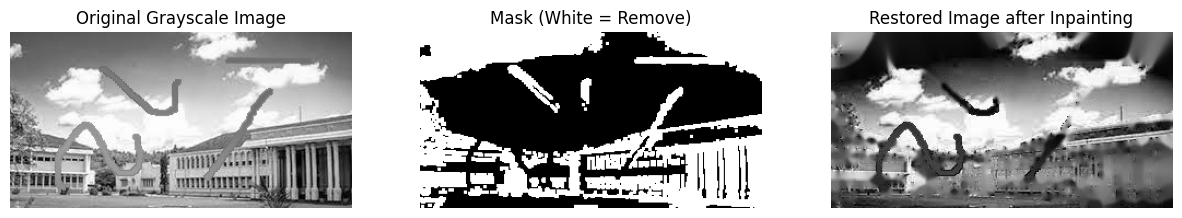

In [27]:

_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

#Dilate Mask: Make the mask slightly thicker to cover edges of scribbles
kernel = np.ones((3,3), np.uint8)
mask = cv2.dilate(mask, kernel, iterations=1)

# Apply Inpainting: Use Telea algorithm with radius 3
restored = cv2.inpaint(gray, mask, 3, cv2.INPAINT_TELEA)

# Display Results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title('Original Grayscale Image')
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Mask (White = Remove)')
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Restored Image after Inpainting')
plt.imshow(restored, cmap='gray')
plt.axis('off')

plt.show()

#### Observation & Description:-
 In this task, I used a threshold of 120 to create the mask.  The result was not good. The mask selected the dark parts of the building instead of the scribbles. In the restored image, the scribbles are still visible, and the building looks very blurry and artificial. This happened because the building shadows are darker than the grey scribbles.

#### Discussion:-
 The inpainting algorithm (cv2.INPAINT_TELEA) tries to fill the white areas of the mask by copying colors from nearby pixels.  Because my mask was wrong, the algorithm erased the building and filled it with surrounding colors. The fill does not blend well because the mask is too big and covers the wrong objects. To fix this, I need a better way to select only the scribbles, like using a range of colors.

#### More to Think :-

Question:- How does inpainting hallucinate incorrect content on complex textures? 
Answer:- Inpainting "hallucinates" because it only looks at the colors of surrounding pixels.  It does not understand what a window or a roof is. On a complex texture like a building with many lines, the algorithm just smears the nearby colors into the hole. It creates a smooth, blurry area where there should be sharp details. This makes the image look fake

### Final Reflection
- Describe how segmentation helps preparation for inpainting and why edge protection is crucial
in restoration tasks.

Segmentation is the first step for a good restoration. It creates a "mask" that tells the computer exactly which part is damaged.  If the segmentation is bad, the inpainting tool will destroy the good parts of the photo. Edge protection is also very important.  If we lose the sharp edges of the building, the photo looks like a blurry painting. We need to keep the structure edges safe so the final result looks like a real photo again.
